In [2]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Propensity Score Matching

In [3]:
num = 100000
np.random.seed(0)
# Generate synthetic data
# Z1 and Z2 are independent variables
# X is a binary treatment variable influenced by Z1 and Z2
# Y is the outcome variable influenced by X, Z1, and Z2


Z1 = np.random.normal(0, 1, num)
Z2 = np.random.normal(0, 1, num)
log_odds = 2 * Z1 - Z2 + np.random.normal(0, 1, num)

# Convert log odds to probability
# The logistic function is used to convert log odds to probability
p = 1 / (1 + np.exp(-log_odds))
# Generate binary treatment variable X based on the probability p

X = np.random.binomial(1, p)
# Y is the outcome variable influenced by X, Z1, and Z2
# Here, we assume a linear relationship for simplicity
Y = 3 * X + Z1 + 0.5 * Z2 + np.random.normal(0, 1, num)

df = pd.DataFrame({'Z1': Z1, 'Z2': Z2, 'X': X, 'Y': Y})

In [ ]:
# Now, we are going to make a model that assigns propensity scores.


# This model will predict the propensity score, which is the probability of receiving the treatment (X = 1) given the observed covariates (Z1, Z2)
# This is a common step in causal inference to control for confounding variables
# Fit a logistic regression model to estimate propensity scores and then train the model on the data where X is known
# We will then use this propensity score to match treated and untreated units to create a balanced comparison group and control for confounding variables and estimate causal effects
# Propensity score matching is a statistical technique used to reduce selection bias by matching treated and untreated units based on their propensity scores


# This is often used in observational studies to estimate causal effects 

model = LogisticRegression()
model.fit(df[['Z1', 'Z2']], df['X'])
df['propensity_score'] = model.predict_proba(df[['Z1', 'Z2']])[:, 1] # 0 and 1 are probabilities of false and of true

# Now we'll match X = 0 to X = 1
treated = df[df['X'] == 1]
untreated = df[df['X'] == 0]

neighbors = NearestNeighbors(n_neighbors=1)
neighbors.fit(untreated[['propensity_score']])
distances_treated_cf, indices_treated_cf = neighbors.kneighbors(treated[['propensity_score']])

treated_cf = untreated.iloc[indices_treated_cf.ravel()].reset_index(drop = True)
treated = treated.reset_index(drop=True).copy()
treated.Y.mean() - treated_cf.Y.mean() # treated_cf => untreated items which are the counterfactuals of treated items

3.0205763354894253

In [ ]:
# calculate the average treatment effect on the treated (ATT)
# This is the difference in means between the treated group and the matched untreated group
# The ATT is a common measure in causal inference to estimate the effect of a treatment on those who actually received it

distance_treated_cf, indices_treated_cf = neighbors.radius_neighbors(treated[["propensity_score"]], 0.1)
treated.Y.mean() - np.mean([untreated.iloc[arr].Y.mean() for arr in indices_treated_cf])

3.082406258414715

In [6]:
pd.concat((treated.mean(), treated_cf.mean()), axis = 1)

,0,1
Z1,0.528904,0.519632
Z2,-0.257774,-0.275110
X,1.000000,0.000000
Y,3.403856,0.383280
propensity_score,0.689250,0.689246


In [7]:
pd.concat((treated.std(), treated_cf.std()), axis = 1)

,0,1
Z1,0.844399,0.829514
Z2,0.963822,0.993123
X,0.000000,0.000000
Y,1.441587,1.437210
propensity_score,0.242074,0.242068


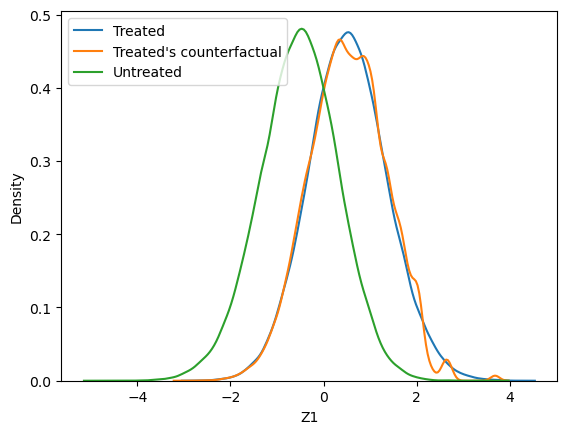

In [8]:
sns.kdeplot(treated.Z1, label = "Treated")
sns.kdeplot(treated_cf.Z1, label = "Treated's counterfactual")
sns.kdeplot(untreated.Z1, label = "Untreated")
plt.gca().legend()

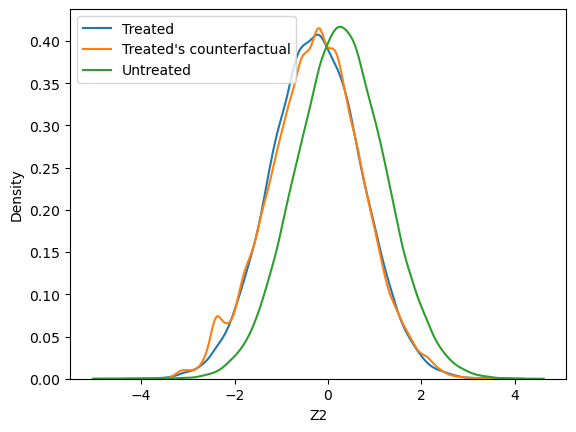

In [9]:
sns.kdeplot(treated.Z2, label = "Treated")
sns.kdeplot(treated_cf.Z2, label = "Treated's counterfactual")
sns.kdeplot(untreated.Z2, label = "Untreated")
plt.gca().legend()

In [10]:
att = np.mean(treated['Y'].values - treated_cf['Y'].values)
print(f"Estimated ATT: {att:.2f}")

Estimated ATT: 3.02


# Inverse Probability Weighting

(array([9.1727e+04, 5.2290e+03, 1.4680e+03, 6.2400e+02, 3.4000e+02,
        1.6100e+02, 1.1400e+02, 7.8000e+01, 4.9000e+01, 3.7000e+01,
        2.9000e+01, 2.6000e+01, 1.7000e+01, 1.4000e+01, 1.3000e+01,
        9.0000e+00, 4.0000e+00, 5.0000e+00, 7.0000e+00, 4.0000e+00,
        4.0000e+00, 6.0000e+00, 6.0000e+00, 6.0000e+00, 4.0000e+00,
        2.0000e+00, 1.0000e+00, 3.0000e+00, 2.0000e+00, 1.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

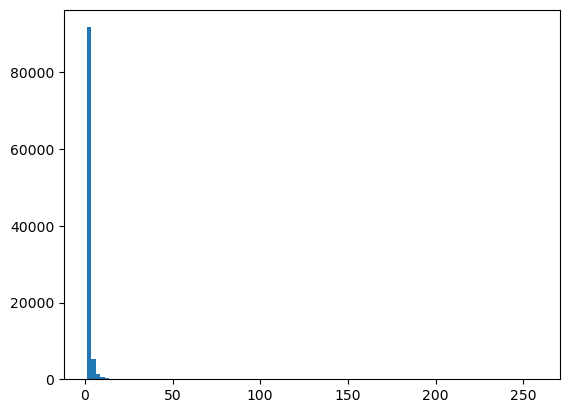

In [11]:
df['ipw'] = (df.X == 1) * (1 / df['propensity_score']) + (df.X == 0) * (1 / (1 - df['propensity_score']))
plt.hist(df.ipw, bins = 100)

# Weighting with regression

Estimated ATE via IPW: 3.170030
Estimated ATE without matching: 3.7965881825414716


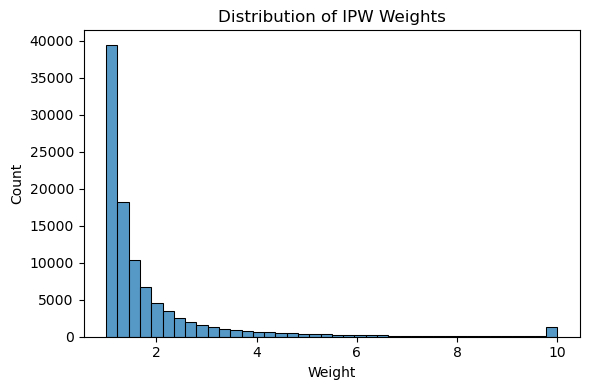

In [12]:
df['ipw'] = np.where(df['X'] == 1, 1 / df['propensity_score'], 1 / (1 - df['propensity_score']))

# If weights are above 10 (probability < 10% or > 90%) it could cause instability - or does this actually not help?
df['ipw_clipped'] = np.clip(df['ipw'], 0, 10)

X_design = sm.add_constant(df['X'])
weighted_model = sm.WLS(df['Y'], X_design, weights=df['ipw_clipped']).fit()
ate_ipw = weighted_model.params['X']
print(f"Estimated ATE via IPW: {ate_ipw:.6f}")
print(f"Estimated ATE without matching: {treated.Y.mean() - untreated.Y.mean()}")

# Plot weights
plt.figure(figsize=(6, 4))
sns.histplot(df['ipw_clipped'], bins=40, kde=False)
plt.title('Distribution of IPW Weights')
plt.xlabel('Weight')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Weighting without regression

In [13]:
treated = df[df.X == 1]
untreated = df[df.X == 0]
treated_mean = np.sum(treated['ipw_clipped'] * treated['Y']) / np.sum(treated['ipw_clipped'])
untreated_mean = np.sum(untreated['ipw_clipped'] * untreated['Y']) / np.sum(untreated['ipw_clipped'])
print(f"ATE = {treated_mean - untreated_mean:.6f}")

ATE = 3.170030


# Curse of dimensionality

/var/folders/z_/3w4wn_0x6c36h1pzzf2nkpj40000gn/T/ipykernel_54459/4193401780.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Y"] = df["X"] + df.drop(columns = "X").dot(coefs2)


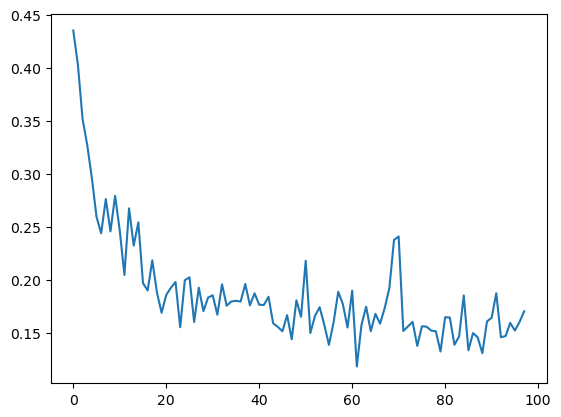

In [14]:
def dimensionality_estimate(dim):
    df = pd.DataFrame()
    coefs1 = np.random.uniform(0, 1, dim)
    coefs2 = np.random.uniform(0, 1, dim)
    num = 1000
    for n in range(dim):
        df[f"Z{n}"] = np.random.normal(0, 1, num)
    df["X"] = np.random.binomial(1, 1 / (1 + np.exp(df.dot(coefs1))))
    df["Y"] = df["X"] + df.drop(columns = "X").dot(coefs2)
    rmse_list = list()
    for _ in range(100):
        samp = df.sample(2)
        rmse_list.append(root_mean_squared_error(samp.iloc[0].drop(columns = ["X", "Y"]), samp.iloc[1].drop(columns = ["X", "Y"])))
    return np.std(rmse_list), np.mean(rmse_list)

dimlist = list()
for n in range(2, 100):
    s, m = dimensionality_estimate(n)
    dimlist.append(s / m)

plt.plot(dimlist)

In [15]:
def dimensionality_estimate(dim, with_print = True, with_plot = False):
    df = pd.DataFrame()
    num_Zs = dim
    for n in range(num_Zs):
        df[f"Z{n}"] = np.random.normal(0, 1, (num,))
    confound_coefs = np.random.uniform(0, 1, num_Zs)
    X = np.random.binomial(1, 1 / (1 + np.exp(df.dot(confound_coefs))), (num,))
    Y_coefs = np.random.uniform(0, 1, num_Zs)
    Y = X + df.dot(Y_coefs)
    df["X"] = X
    df["Y"] = Y
    treated = df[df.X == 1]
    untreated = df[df.X == 0]
    neighbors = NearestNeighbors(n_neighbors = 1).fit(untreated.drop(columns = ["Y", "X"]), Y)
    distances_treated_cf, indices_treated_cf = neighbors.kneighbors(treated.drop(columns = ["Y", "X"]))
    treated_cf = untreated.iloc[indices_treated_cf.ravel()].reset_index(drop = True)
    treated = treated.reset_index(drop = True)
    if(with_print):
        print(f"ATT for dim = {dim} is {treated.Y.mean() - treated_cf.Y.mean()}")
    lst = list()
    for n in range(1000):
        samp = df.sample(2)
        rmse = root_mean_squared_error(samp.iloc[0].drop(columns = ["X", "Y"]), samp.iloc[1].drop(columns = ["X", "Y"]))
        lst.append(rmse)
    if(with_plot):
        plt.hist(lst)
    return(np.array(lst).mean(), np.array(lst).std())

In [16]:
for n in range(1, 10):
    dimensionality_estimate(n)

ATT for dim = 1 is 0.9999356148717963
ATT for dim = 2 is 0.9985103921875171
ATT for dim = 3 is 0.9912121981407745
ATT for dim = 4 is 0.9768150843936814
ATT for dim = 5 is 0.9590798758757824
ATT for dim = 6 is 0.7990177837415712
ATT for dim = 7 is 0.8015832248349957
ATT for dim = 8 is 0.66375821956111
ATT for dim = 9 is 0.6231935009571943


In [17]:
sum([dimensionality_estimate(2, with_print = False)[0] for _ in range(20)]) / 20

1.0924436244719433

In [18]:
sum([dimensionality_estimate(2, with_print = False)[1] for _ in range(20)]) / 20

0.4931223130688295

/var/folders/z_/3w4wn_0x6c36h1pzzf2nkpj40000gn/T/ipykernel_54459/71880550.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["X"] = X
/var/folders/z_/3w4wn_0x6c36h1pzzf2nkpj40000gn/T/ipykernel_54459/71880550.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Y"] = Y


ATT for dim = 100 is -3.7674341019343442


(1.5632440131630625, 0.22429250585367805)

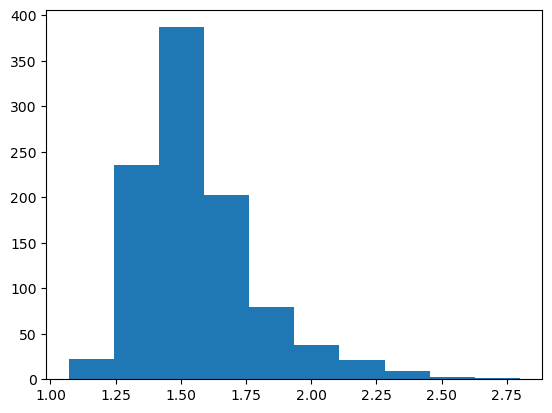

In [19]:
dimensionality_estimate(100, with_plot = True)

In [20]:
# Simpler dataset

In [21]:
def rmse_std_vs_dim(dim, num_samples=1000):
    rmses = []
    for _ in range(num_samples):
        x = np.random.normal(0, 1, dim)
        y = np.random.normal(0, 1, dim)
        rmse = np.sqrt(np.mean((x - y) ** 2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

for d in [2, 10, 50, 100]:
    mean_rmse, std_rmse = rmse_std_vs_dim(d)
    print(f"dim={d:3d} | mean RMSE ≈ {mean_rmse:.3f} | std ≈ {std_rmse:.4f}")

dim=  2 | mean RMSE ≈ 1.194 | std ≈ 0.6555
dim= 10 | mean RMSE ≈ 1.366 | std ≈ 0.3140
dim= 50 | mean RMSE ≈ 1.406 | std ≈ 0.1437
dim=100 | mean RMSE ≈ 1.409 | std ≈ 0.0986
